In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

PICKUP_OBJECT   =  25
WALL_COLLIDE    = -10
OBJECT_COLLIDE  =  -5
WATER           = -20
CABLE           = -20
BLANK_SQUARE    =  -1
FINAL_REWARD    = 200

list_grid_squares = [(x, y) for y in range(8) for x in range(8)]
obstacle_squares  = set([(2,0),(1,2),(0,4),(1,6),(2,6),(4,4),(5,1),(5,6),(6,6),(7,2)])
pickup_squares    = set([(1,3),(1,7),(6,4)])
water_square      = {(3,4)}
cable_square      = {(5,2)}
exit_square       = {(7,0)}
blank_squares     = set(list_grid_squares) - obstacle_squares - water_square - cable_square
pickup_locs       = {'P_1': (1,3), 'P_2': (1,7), 'P_3': (6,4)}

moves = {0: (-1,0), 1:(1,0), 2:(0,1), 3:(0,-1)}

pickup_states       = {(0,0,0):0,(1,0,0):1,(0,1,0):2,(0,0,1):3,
                       (1,1,0):4,(0,1,1):5,(1,0,1):6,(1,1,1):7}
index_to_pickup_state = {v: k for k, v in pickup_states.items()}
ALL_PICKUP_INDEX    = 7
goal_state          = 511   # (7,0) + all pickups

GRID_SIZE, NUM_PICKUP_STATES, NUM_DIRECTIONS = 64, 8, 4
R = np.full((GRID_SIZE * NUM_PICKUP_STATES, NUM_DIRECTIONS), np.nan)

for grid_index, (x, y) in enumerate(list_grid_squares):
    for pickup_index in range(NUM_PICKUP_STATES):
        row = grid_index * 8 + pickup_index
        for move, (dx, dy) in moves.items():
            new_coord = (x + dx, y + dy)
            nx, ny = new_coord
            if nx < 0 or nx > 7 or ny < 0 or ny > 7:
                R[row, move] = WALL_COLLIDE
            elif new_coord in obstacle_squares:
                R[row, move] = OBJECT_COLLIDE
            elif new_coord in water_square:
                R[row, move] = WATER
            elif new_coord in cable_square:
                R[row, move] = CABLE
            elif new_coord in pickup_squares:
                R[row, move] = PICKUP_OBJECT
            elif new_coord in exit_square:
                R[row, move] = FINAL_REWARD if pickup_index == ALL_PICKUP_INDEX else BLANK_SQUARE
            else:
                R[row, move] = BLANK_SQUARE


def index_to_coord_pickup(i):
    coord   = list_grid_squares[i // 8]
    pickup  = index_to_pickup_state[i % 8]
    return coord, pickup

pickup_object_collections = {0: False, 1: False, 2: False}

def step(s, a):
    coord, pickup = index_to_coord_pickup(s)
    dx, dy = moves[int(a)]
    new_coord = (coord[0] + dx, coord[1] + dy)
    reward = R[s, a]
    new_pickup = list(pickup)
    n_picked = 0
    for i, key in enumerate(['P_1', 'P_2', 'P_3']):
        if new_coord == pickup_locs[key] and not pickup_object_collections[i]:
            new_pickup[i] = 1
            pickup_object_collections[i] = True
            n_picked += 1
    if new_coord in list_grid_squares and new_coord not in obstacle_squares:
        new_grid_idx   = list_grid_squares.index(new_coord)
        new_pickup_idx = pickup_states[tuple(new_pickup)]
        new_s = new_grid_idx * 8 + new_pickup_idx
    else:
        new_s = s
    return new_s, reward, n_picked

print(" Environment ready. R matrix shape:", R.shape)
print("   Obstacles:", len(obstacle_squares), "| Pickups:", len(pickup_squares),
      "| Water:", len(water_square), "| Cable:", len(cable_square))

 Environment ready. R matrix shape: (512, 4)
   Obstacles: 10 | Pickups: 3 | Water: 1 | Cable: 1


Q learning with epsilon decay

In [2]:

alpha        = 1.0
gamma        = 0.8
epsilon_start = 0.9
epsilon_end   = 0.05
epsilon_decay = 0.998
NUM_EPISODES  = 2000
MAX_STEPS     = 500

Q_ql = np.zeros(R.shape)

ql_rewards  = []
ql_pickups  = []
ql_steps    = []
ql_epsilons = []

epsilon = epsilon_start

for episode in range(NUM_EPISODES):
    pickup_object_collections = {0: False, 1: False, 2: False}
    s             = 0
    total_reward  = 0
    total_pickups = 0
    ep_steps      = 0

    for t in range(MAX_STEPS):
        ep_steps += 1
        available = np.where(~np.isnan(R[s]))[0]
        q_vals    = Q_ql[s, available]

        if np.random.uniform() < epsilon:
            a = np.random.choice(available)
        else:
            a = np.random.choice(available[q_vals == q_vals.max()])

        s_old = s
        s, r, n_picked = step(s, a)
        total_reward  += r
        total_pickups += n_picked

        best_next = np.nanmax(Q_ql[s, np.where(~np.isnan(R[s]))[0]])
        Q_ql[s_old, a] += alpha * (r + gamma * best_next - Q_ql[s_old, a])

        if s == goal_state:
            break

    ql_rewards.append(total_reward)
    ql_pickups.append(total_pickups)
    ql_steps.append(ep_steps)
    ql_epsilons.append(epsilon)

    epsilon = max(epsilon_end, epsilon * epsilon_decay)

    if (episode + 1) % 200 == 0:
        print(f"Ep {episode+1:4d} | ε={epsilon:.3f} | "
              f"reward={total_reward:7.1f} | pickups={total_pickups} | steps={ep_steps}")

print("\n Q-Learning done.")

Ep  200 | ε=0.603 | reward=16101.0 | pickups=3 | steps=500
Ep  400 | ε=0.404 | reward=14726.0 | pickups=3 | steps=500
Ep  600 | ε=0.271 | reward= 4388.0 | pickups=1 | steps=500
Ep  800 | ε=0.181 | reward= 5139.0 | pickups=1 | steps=500
Ep 1000 | ε=0.122 | reward= 5405.0 | pickups=1 | steps=500
Ep 1200 | ε=0.081 | reward= 5298.0 | pickups=1 | steps=500
Ep 1400 | ε=0.055 | reward= 5575.0 | pickups=1 | steps=500
Ep 1600 | ε=0.050 | reward= 5792.0 | pickups=1 | steps=500
Ep 1800 | ε=0.050 | reward= 5746.0 | pickups=1 | steps=500
Ep 2000 | ε=0.050 | reward= 5728.0 | pickups=1 | steps=500

 Q-Learning done.


SARSA is very similar to q learnign but it choses next action instead of chosing max value (Implementation of SARSA)

In [ ]:

alpha         = 1.0
gamma         = 0.8
epsilon_start = 0.9
epsilon_end   = 0.05
epsilon_decay = 0.998
NUM_EPISODES  = 2000
MAX_STEPS     = 500

Q_sarsa = np.zeros(R.shape)

sarsa_rewards  = []
sarsa_pickups  = []
sarsa_steps    = []

epsilon = epsilon_start

def choose_action(s, Q, eps):
    available = np.where(~np.isnan(R[s]))[0]
    if np.random.uniform() < eps:
        return np.random.choice(available)
    q_vals = Q[s, available]
    return np.random.choice(available[q_vals == q_vals.max()])

for episode in range(NUM_EPISODES):
    pickup_object_collections = {0: False, 1: False, 2: False}
    s             = 0
    total_reward  = 0
    total_pickups = 0
    ep_steps      = 0

    a = choose_action(s, Q_sarsa, epsilon)

    for t in range(MAX_STEPS):
        ep_steps += 1
        s_old = s
        s, r, n_picked = step(s, a)
        total_reward  += r
        total_pickups += n_picked

        a_next = choose_action(s, Q_sarsa, epsilon)

        Q_sarsa[s_old, a] += alpha * (r + gamma * Q_sarsa[s, a_next] - Q_sarsa[s_old, a])

        a = a_next

        if s == goal_state:
            break

    sarsa_rewards.append(total_reward)
    sarsa_pickups.append(total_pickups)
    sarsa_steps.append(ep_steps)

    epsilon = max(epsilon_end, epsilon * epsilon_decay)

    if (episode + 1) % 200 == 0:
        print(f"Ep {episode+1:4d} | ε={epsilon:.3f} | "
              f"reward={total_reward:7.1f} | pickups={total_pickups} | steps={ep_steps}")

print("\n SARSA done.")

Ep  200 | ε=0.603 | reward=  792.0 | pickups=2 | steps=500
Ep  400 | ε=0.404 | reward= 1879.0 | pickups=3 | steps=500
Ep  600 | ε=0.271 | reward= 2894.0 | pickups=1 | steps=500
Ep  800 | ε=0.181 | reward= 3639.0 | pickups=1 | steps=500
Ep 1000 | ε=0.122 | reward= 4289.0 | pickups=2 | steps=500
Ep 1200 | ε=0.081 | reward= 4819.0 | pickups=1 | steps=500
Ep 1400 | ε=0.055 | reward= 5518.0 | pickups=1 | steps=500
Ep 1600 | ε=0.050 | reward= 5120.0 | pickups=1 | steps=500
Ep 1800 | ε=0.050 | reward= 5199.0 | pickups=1 | steps=500
Ep 2000 | ε=0.050 | reward= 5644.0 | pickups=1 | steps=500

 SARSA done.


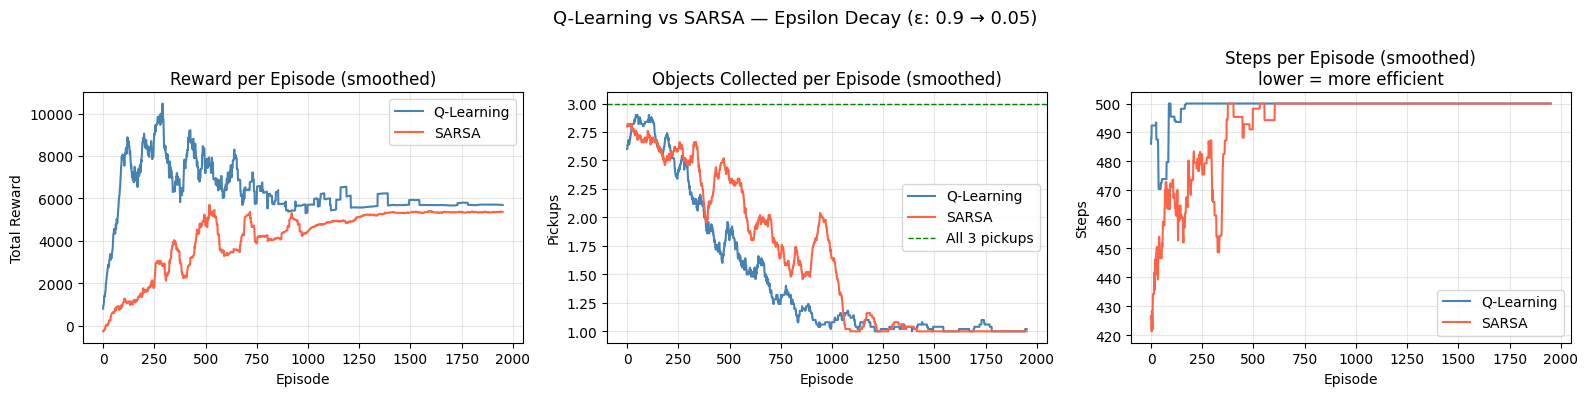

 Plots saved as rl_comparison.png


In [ ]:
def smooth(data, window=50):
    return np.convolve(data, np.ones(window)/window, mode='valid')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Q-Learning vs SARSA — Epsilon Decay (ε: 0.9 → 0.05)", fontsize=13)

ep_axis = np.arange(len(smooth(ql_rewards)))

axes[0].plot(ep_axis, smooth(ql_rewards),    label='Q-Learning', color='steelblue')
axes[0].plot(ep_axis, smooth(sarsa_rewards), label='SARSA',      color='tomato')
axes[0].set_title('Reward per Episode (smoothed)')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Total Reward')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(ep_axis, smooth(ql_pickups),    label='Q-Learning', color='steelblue')
axes[1].plot(ep_axis, smooth(sarsa_pickups), label='SARSA',      color='tomato')
axes[1].axhline(3, color='green', linestyle='--', linewidth=1, label='All 3 pickups')
axes[1].set_title('Objects Collected per Episode (smoothed)')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Pickups')
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(ep_axis, smooth(ql_steps),    label='Q-Learning', color='steelblue')
axes[2].plot(ep_axis, smooth(sarsa_steps), label='SARSA',      color='tomato')
axes[2].set_title('Steps per Episode (smoothed)\nlower = more efficient')
axes[2].set_xlabel('Episode')
axes[2].set_ylabel('Steps')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('rl_comparison.png', dpi=150)
plt.show()
print(" Plots saved as rl_comparison.png")

Greedy path length: 200 steps
Final state pickup: (1, 0, 0)  (should be (1,1,1) if successful)


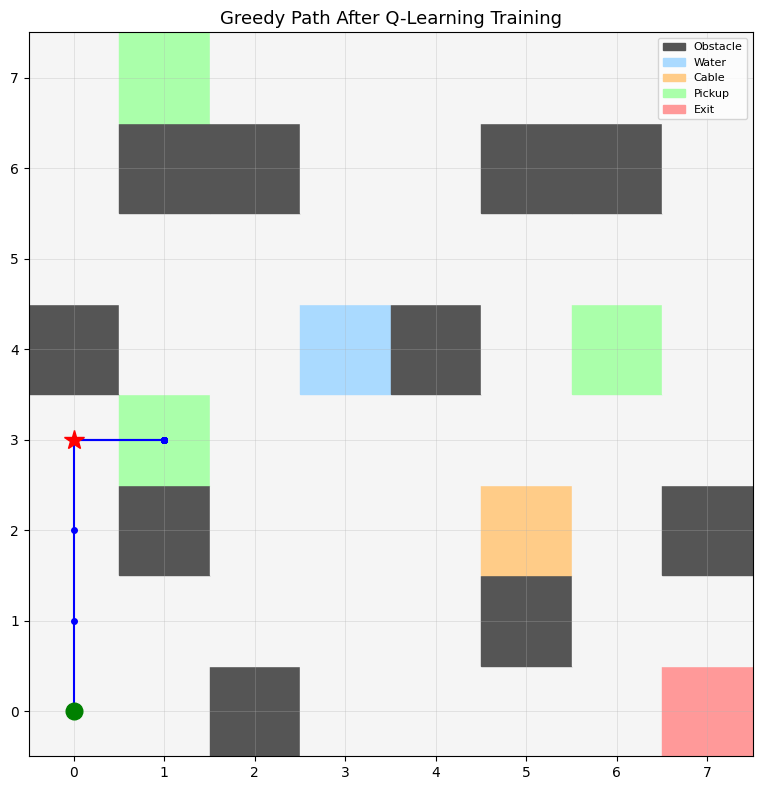

 Path saved as greedy_path.png


In [ ]:
def run_greedy(Q, max_steps=200):
    global pickup_object_collections
    pickup_object_collections = {0: False, 1: False, 2: False}
    s     = 0
    path  = []
    for _ in range(max_steps):
        coord, pickup = index_to_coord_pickup(s)
        path.append((coord, pickup))
        if s == goal_state:
            break
        available = np.where(~np.isnan(R[s]))[0]
        if len(available) == 0:
            break
        a = available[np.argmax(Q_ql[s, available])]
        s, _, _ = step(s, a)
    return path

path = run_greedy(Q_ql)
print(f"Greedy path length: {len(path)} steps")
print(f"Final state pickup: {path[-1][1]}  (should be (1,1,1) if successful)")

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(-0.5, 7.5)
ax.set_ylim(-0.5, 7.5)
ax.set_xticks(range(8))
ax.set_yticks(range(8))
ax.grid(True, linewidth=0.5, alpha=0.4)
ax.set_aspect('equal')
ax.set_title("Greedy Path After Q-Learning Training", fontsize=13)

for x, y in list_grid_squares:
    if (x, y) in obstacle_squares:
        color = '#555555'
    elif (x, y) in water_square:
        color = '#aadaff'
    elif (x, y) in cable_square:
        color = '#ffcc88'
    elif (x, y) in pickup_squares:
        color = '#aaffaa'
    elif (x, y) in exit_square:
        color = '#ff9999'
    else:
        color = '#f5f5f5'
    ax.add_patch(plt.Rectangle((x - 0.5, y - 0.5), 1, 1,
                                color=color, zorder=0))

xs = [c[0] for c, _ in path]
ys = [c[1] for c, _ in path]
ax.plot(xs, ys, 'b-o', markersize=4, linewidth=1.5, zorder=2, label='Path')
ax.plot(xs[0],  ys[0],  'go', markersize=12, zorder=3, label='Start (0,0)')
ax.plot(xs[-1], ys[-1], 'r*', markersize=15, zorder=3, label='End')

legend_items = [
    mpatches.Patch(color='#555555', label='Obstacle'),
    mpatches.Patch(color='#aadaff', label='Water'),
    mpatches.Patch(color='#ffcc88', label='Cable'),
    mpatches.Patch(color='#aaffaa', label='Pickup'),
    mpatches.Patch(color='#ff9999', label='Exit'),
]
ax.legend(handles=legend_items, loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig('greedy_path.png', dpi=150)
plt.show()
print(" Path saved as greedy_path.png")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.animation as animation
from PIL import Image
import io

def run_greedy(Q, max_steps=200):
    global pickup_object_collections
    pickup_object_collections = {0: False, 1: False, 2: False}
    s = 0
    path = []
    for _ in range(max_steps):
        coord, pickup = index_to_coord_pickup(s)
        path.append((coord, pickup))
        if s == goal_state:
            break
        available = np.where(~np.isnan(R[s]))[0]
        if len(available) == 0:
            break
        a = available[np.argmax(Q_ql[s, available])]
        s, _, _ = step(s, a)
    return path

path = run_greedy(Q_ql)
print(f"Greedy path length: {len(path)} steps")
print(f"Final pickup state: {path[-1][1]}  (goal = (1,1,1))")

CELL_COLORS = {
    'obstacle': '#555555',
    'water':    '#aadaff',
    'cable':    '#ffcc88',
    'pickup':   '#aaffaa',
    'exit':     '#ff9999',
    'blank':    '#f5f5f5',
}

def cell_color(coord, collected_pickups):
    x, y = coord
    if coord in obstacle_squares: return CELL_COLORS['obstacle']
    if coord in water_square:     return CELL_COLORS['water']
    if coord in cable_square:     return CELL_COLORS['cable']
    if coord in exit_square:      return CELL_COLORS['exit']
    if coord in pickup_squares:
        idx = list(pickup_locs.values()).index(coord)
        return '#cccccc' if collected_pickups[idx] else CELL_COLORS['pickup']
    return CELL_COLORS['blank']

def draw_frame(ax, step_idx):
    ax.clear()
    ax.set_xlim(-0.5, 7.5)
    ax.set_ylim(-0.5, 7.5)
    ax.set_xticks(range(8))
    ax.set_yticks(range(8))
    ax.grid(True, linewidth=0.5, alpha=0.4)
    ax.set_aspect('equal')

    coord, pickup = path[step_idx]
    collected = list(pickup)

    for x, y in list_grid_squares:
        color = cell_color((x, y), collected)
        ax.add_patch(plt.Rectangle((x-0.5, y-0.5), 1, 1, color=color, zorder=0))

    if step_idx > 0:
        trail_x = [p[0][0] for p in path[:step_idx]]
        trail_y = [p[0][1] for p in path[:step_idx]]
        ax.plot(trail_x, trail_y, 'b-', linewidth=1.5, alpha=0.3, zorder=1)

    ax.plot(coord[0], coord[1], 'bo', markersize=14, zorder=3)
    ax.plot(path[0][0][0], path[0][0][1], 'go', markersize=10, zorder=2, label='Start')
    p_status = ' | '.join([
        f"P{i+1}:{'✓' if collected[i] else '✗'}" for i in range(3)
    ])
    ax.set_title(f"Step {step_idx+1}/{len(path)}   {p_status}", fontsize=11)

    legend_items = [
        mpatches.Patch(color=CELL_COLORS['obstacle'], label='Obstacle'),
        mpatches.Patch(color=CELL_COLORS['water'],    label='Water (-20)'),
        mpatches.Patch(color=CELL_COLORS['cable'],    label='Cable (-20)'),
        mpatches.Patch(color=CELL_COLORS['pickup'],   label='Pickup (+25)'),
        mpatches.Patch(color='#cccccc',               label='Collected'),
        mpatches.Patch(color=CELL_COLORS['exit'],     label='Exit (+200)'),
    ]
    ax.legend(handles=legend_items, loc='upper right', fontsize=7)

fig, ax = plt.subplots(figsize=(7, 7))
ani = animation.FuncAnimation(
    fig,
    lambda i: draw_frame(ax, i),
    frames=len(path),
    interval=300,
    repeat=False
)

gif_writer = animation.PillowWriter(fps=4)
ani.save('greedy_path.gif', writer=gif_writer, dpi=100)
print(" GIF saved → greedy_path.gif")

try:
    mp4_writer = animation.FFMpegWriter(fps=4, bitrate=1800)
    ani.save('greedy_path.mp4', writer=mp4_writer, dpi=120)
    print(" MP4 saved → greedy_path.mp4")
except Exception as e:
    print(f" MP4 skipped (ffmpeg not found): {e}")
    print("   Install with:  conda install ffmpeg  or  pip install imageio-ffmpeg")

plt.close()

Greedy path length: 200 steps
Final pickup state: (1, 0, 0)  (goal = (1,1,1))
 GIF saved → greedy_path.gif
 MP4 saved → greedy_path.mp4


The following approaches seemed correct :
1. Grid setup (8×8)
2. State design (512 states)
3. Actions and movement
4. Q-learning structure
But the few problems were noticed in the code
1. Goal state definition
2. Pickup tracking/reset
3. Reward logic


The robot was not learning anything, as the decision given by the local variable tracking the pickups and the global vairables was leading to disagreement and hence showing unwanted behaviour

In [3]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
PICKUP_OBJECT  =  25
WALL_COLLIDE   = -10
OBJECT_COLLIDE =  -5
WATER          = -20
CABLE          = -20
BLANK_SQUARE   =  -1
FINAL_REWARD   = 200

list_grid_squares = [(x, y) for y in range(8) for x in range(8)]
obstacle_squares  = set([(2,0),(1,2),(0,4),(1,6),(2,6),(4,4),(5,1),(5,6),(6,6),(7,2)])
pickup_squares    = set([(1,3),(1,7),(6,4)])
water_square      = {(3,4)}
cable_square      = {(5,2)}
exit_square       = {(7,0)}
blank_squares     = set(list_grid_squares) - obstacle_squares - water_square - cable_square
pickup_locs       = {'P_1': (1,3), 'P_2': (1,7), 'P_3': (6,4)}

moves = {0: (-1,0), 1:(1,0), 2:(0,1), 3:(0,-1)}

pickup_states         = {(0,0,0):0,(1,0,0):1,(0,1,0):2,(0,0,1):3,
                         (1,1,0):4,(0,1,1):5,(1,0,1):6,(1,1,1):7}
index_to_pickup_state = {v: k for k, v in pickup_states.items()}
ALL_PICKUP_INDEX      = 7

goal_state = list_grid_squares.index((7,0)) * 8 + ALL_PICKUP_INDEX
print(f" goal_state = {goal_state}  (grid index of (7,0) = {list_grid_squares.index((7,0))})")

coord_to_index = {coord: i for i, coord in enumerate(list_grid_squares)}

GRID_SIZE, NUM_PICKUP_STATES, NUM_DIRECTIONS = 64, 8, 4
R = np.full((GRID_SIZE * NUM_PICKUP_STATES, NUM_DIRECTIONS), np.nan)

for grid_index, (x, y) in enumerate(list_grid_squares):
    for pickup_index in range(NUM_PICKUP_STATES):
        row = grid_index * 8 + pickup_index
        for move, (dx, dy) in moves.items():
            new_coord = (x + dx, y + dy)
            nx, ny = new_coord
            if nx < 0 or nx > 7 or ny < 0 or ny > 7:
                R[row, move] = WALL_COLLIDE
            elif new_coord in obstacle_squares:
                R[row, move] = OBJECT_COLLIDE
            elif new_coord in water_square:
                R[row, move] = WATER
            elif new_coord in cable_square:
                R[row, move] = CABLE
            elif new_coord in pickup_squares:

                pickup_tuple = index_to_pickup_state[pickup_index]
                pickup_list  = list(pickup_locs.values())
                p_idx = pickup_list.index(new_coord)
                if pickup_tuple[p_idx] == 0:
                    R[row, move] = PICKUP_OBJECT
                else:
                    R[row, move] = BLANK_SQUARE
            elif new_coord in exit_square:
                R[row, move] = FINAL_REWARD if pickup_index == ALL_PICKUP_INDEX else BLANK_SQUARE
            else:
                R[row, move] = BLANK_SQUARE

def index_to_coord_pickup(i):
    coord  = list_grid_squares[i // 8]
    pickup = index_to_pickup_state[i % 8]
    return coord, pickup

def step(s, a):

    coord, pickup = index_to_coord_pickup(s)
    dx, dy = moves[int(a)]
    new_coord = (coord[0] + dx, coord[1] + dy)
    reward    = R[s, a]
    new_pickup = list(pickup)
    n_picked   = 0

    for i, key in enumerate(['P_1', 'P_2', 'P_3']):
        if new_coord == pickup_locs[key] and pickup[i] == 0:
            new_pickup[i] = 1
            n_picked += 1

    if new_coord in coord_to_index and new_coord not in obstacle_squares:
        new_grid_idx   = coord_to_index[new_coord]
        new_pickup_idx = pickup_states[tuple(new_pickup)]
        new_s = new_grid_idx * 8 + new_pickup_idx
    else:
        new_s = s

    return new_s, reward, n_picked

print(" Environment ready. R matrix shape:", R.shape)
print(f"   Obstacles: {len(obstacle_squares)} | Pickups: {len(pickup_squares)} "
      f"| Water: {len(water_square)} | Cable: {len(cable_square)}")

assert goal_state < R.shape[0], "goal_state out of bounds!"
exit_coord, exit_pickup = index_to_coord_pickup(goal_state)
assert exit_coord == (7,0),      f"Goal coord wrong: {exit_coord}"
assert exit_pickup == (1,1,1),   f"Goal pickup wrong: {exit_pickup}"

exit_grid_idx = coord_to_index[(7,0)]
row_before_exit = (coord_to_index[(6,0)]) * 8 + ALL_PICKUP_INDEX
print(f"\n Sanity checks passed:")
print(f"   goal_state {goal_state} → coord={exit_coord}, pickups={exit_pickup}")
print(f"   R at exit entry with all pickups: {R[row_before_exit, 1]} (should be 200.0)")
print(f"   R at exit entry WITHOUT all pickups: {R[coord_to_index[(6,0)]*8 + 0, 1]} (should be -1.0)")

 goal_state = 63  (grid index of (7,0) = 7)
 Environment ready. R matrix shape: (512, 4)
   Obstacles: 10 | Pickups: 3 | Water: 1 | Cable: 1

 Sanity checks passed:
   goal_state 63 → coord=(7, 0), pickups=(1, 1, 1)
   R at exit entry with all pickups: 200.0 (should be 200.0)
   R at exit entry WITHOUT all pickups: -1.0 (should be -1.0)


In [4]:
alpha         = 1.0
gamma         = 0.8
epsilon_start = 0.9
epsilon_end   = 0.05
epsilon_decay = 0.998
NUM_EPISODES  = 2000
MAX_STEPS     = 500

Q_ql = np.zeros(R.shape)

ql_rewards  = []
ql_pickups  = []
ql_steps    = []
ql_epsilons = []

epsilon = epsilon_start

for episode in range(NUM_EPISODES):

    s             = 0
    total_reward  = 0
    total_pickups = 0
    ep_steps      = 0

    for t in range(MAX_STEPS):
        ep_steps += 1
        available = np.where(~np.isnan(R[s]))[0]
        q_vals    = Q_ql[s, available]

        if np.random.uniform() < epsilon:
            a = np.random.choice(available)
        else:
            a = np.random.choice(available[q_vals == q_vals.max()])

        s_old = s
        s, r, n_picked = step(s, a)
        total_reward  += r
        total_pickups += n_picked

        best_next = np.nanmax(Q_ql[s, np.where(~np.isnan(R[s]))[0]])
        Q_ql[s_old, a] += alpha * (r + gamma * best_next - Q_ql[s_old, a])

        if s == goal_state:
            break

    ql_rewards.append(total_reward)
    ql_pickups.append(total_pickups)
    ql_steps.append(ep_steps)
    ql_epsilons.append(epsilon)

    epsilon = max(epsilon_end, epsilon * epsilon_decay)

    if (episode + 1) % 200 == 0:
        print(f"Ep {episode+1:4d} | ε={epsilon:.3f} | "
              f"reward={total_reward:7.1f} | pickups={total_pickups} | steps={ep_steps}")

print("\n Q-Learning done.")

Ep  200 | ε=0.603 | reward=  125.0 | pickups=3 | steps=58
Ep  400 | ε=0.404 | reward=  186.0 | pickups=3 | steps=49
Ep  600 | ε=0.271 | reward=  218.0 | pickups=3 | steps=35
Ep  800 | ε=0.181 | reward=  241.0 | pickups=3 | steps=26
Ep 1000 | ε=0.122 | reward=  246.0 | pickups=3 | steps=24
Ep 1200 | ε=0.081 | reward=  254.0 | pickups=3 | steps=25
Ep 1400 | ε=0.055 | reward=  256.0 | pickups=3 | steps=23
Ep 1600 | ε=0.050 | reward=  256.0 | pickups=3 | steps=23
Ep 1800 | ε=0.050 | reward=  256.0 | pickups=3 | steps=23
Ep 2000 | ε=0.050 | reward=  246.0 | pickups=3 | steps=24

 Q-Learning done.


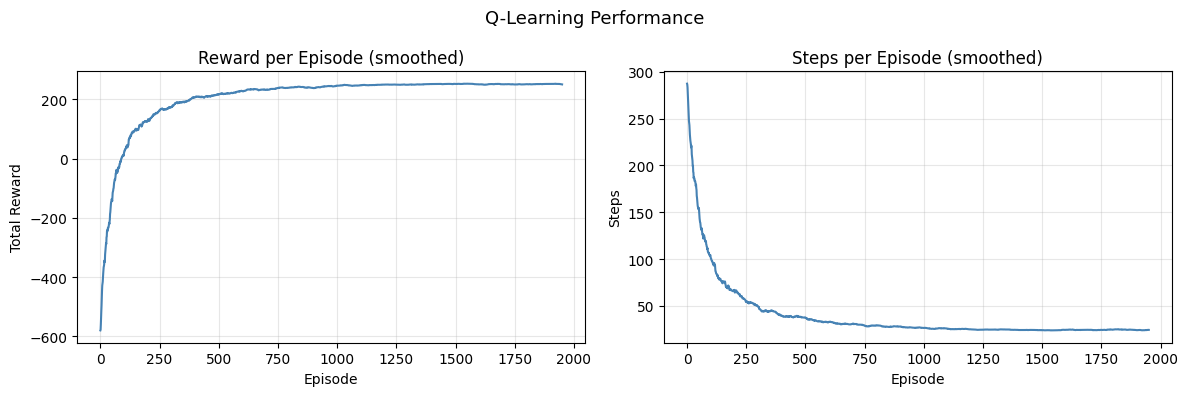

In [8]:
def smooth(data, window=50):
    return np.convolve(data, np.ones(window)/window, mode='valid')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Q-Learning Performance", fontsize=13)

ep_axis = np.arange(len(smooth(ql_rewards)))

axes[0].plot(ep_axis, smooth(ql_rewards), color='steelblue')
axes[0].set_title('Reward per Episode (smoothed)')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Total Reward')
axes[0].grid(alpha=0.3)

axes[1].plot(ep_axis, smooth(ql_steps), color='steelblue')
axes[1].set_title('Steps per Episode (smoothed)')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Steps')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('qlearning_performance.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:

alpha         = 1.0
gamma         = 0.8
epsilon_start = 0.9
epsilon_end   = 0.05
epsilon_decay = 0.998
NUM_EPISODES  = 2000
MAX_STEPS     = 500

Q_sarsa = np.zeros(R.shape)

sarsa_rewards = []
sarsa_pickups = []
sarsa_steps   = []

epsilon = epsilon_start

def choose_action(s, Q, eps):
    available = np.where(~np.isnan(R[s]))[0]
    if np.random.uniform() < eps:
        return np.random.choice(available)
    q_vals = Q[s, available]
    return np.random.choice(available[q_vals == q_vals.max()])

for episode in range(NUM_EPISODES):
    s             = 0
    total_reward  = 0
    total_pickups = 0
    ep_steps      = 0

    a = choose_action(s, Q_sarsa, epsilon)

    for t in range(MAX_STEPS):
        ep_steps += 1
        s_old = s
        s, r, n_picked = step(s, a)
        total_reward  += r
        total_pickups += n_picked

        a_next = choose_action(s, Q_sarsa, epsilon)
        Q_sarsa[s_old, a] += alpha * (r + gamma * Q_sarsa[s, a_next] - Q_sarsa[s_old, a])
        a = a_next

        if s == goal_state:
            break

    sarsa_rewards.append(total_reward)
    sarsa_pickups.append(total_pickups)
    sarsa_steps.append(ep_steps)

    epsilon = max(epsilon_end, epsilon * epsilon_decay)

    if (episode + 1) % 200 == 0:
        print(f"Ep {episode+1:4d} | ε={epsilon:.3f} | "
              f"reward={total_reward:7.1f} | pickups={total_pickups} | steps={ep_steps}")

print("\n SARSA done.")

Ep  200 | ε=0.603 | reward= -400.0 | pickups=3 | steps=325
Ep  400 | ε=0.404 | reward= -113.0 | pickups=3 | steps=239
Ep  600 | ε=0.271 | reward=  105.0 | pickups=3 | steps=85
Ep  800 | ε=0.181 | reward=    3.0 | pickups=3 | steps=233
Ep 1000 | ε=0.122 | reward=  133.0 | pickups=3 | steps=90
Ep 1200 | ε=0.081 | reward=  220.0 | pickups=3 | steps=36
Ep 1400 | ε=0.055 | reward=   70.0 | pickups=3 | steps=186
Ep 1600 | ε=0.050 | reward=  222.0 | pickups=3 | steps=39
Ep 1800 | ε=0.050 | reward=  240.0 | pickups=3 | steps=39
Ep 2000 | ε=0.050 | reward=  246.0 | pickups=3 | steps=33

 SARSA done.


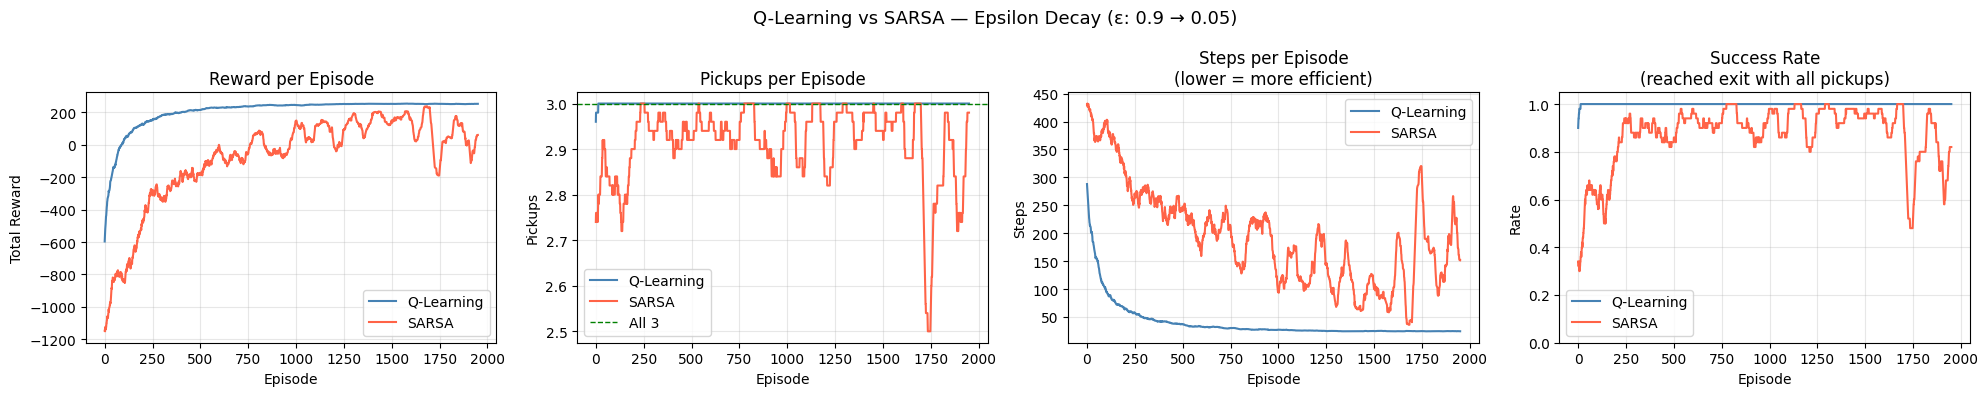

 Plots saved.


In [ ]:

def smooth(data, window=50):
    return np.convolve(data, np.ones(window)/window, mode='valid')

ql_success    = [1 if steps < MAX_STEPS else 0 for steps in ql_steps]
sarsa_success = [1 if steps < MAX_STEPS else 0 for steps in sarsa_steps]

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle("Q-Learning vs SARSA — Epsilon Decay (ε: 0.9 → 0.05)", fontsize=13)

ep_axis = np.arange(len(smooth(ql_rewards)))

axes[0].plot(ep_axis, smooth(ql_rewards),    label='Q-Learning', color='steelblue')
axes[0].plot(ep_axis, smooth(sarsa_rewards), label='SARSA',      color='tomato')
axes[0].set_title('Reward per Episode')
axes[0].set_xlabel('Episode'); axes[0].set_ylabel('Total Reward')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep_axis, smooth(ql_pickups),    label='Q-Learning', color='steelblue')
axes[1].plot(ep_axis, smooth(sarsa_pickups), label='SARSA',      color='tomato')
axes[1].axhline(3, color='green', linestyle='--', linewidth=1, label='All 3')
axes[1].set_title('Pickups per Episode')
axes[1].set_xlabel('Episode'); axes[1].set_ylabel('Pickups')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(ep_axis, smooth(ql_steps),    label='Q-Learning', color='steelblue')
axes[2].plot(ep_axis, smooth(sarsa_steps), label='SARSA',      color='tomato')
axes[2].set_title('Steps per Episode\n(lower = more efficient)')
axes[2].set_xlabel('Episode'); axes[2].set_ylabel('Steps')
axes[2].legend(); axes[2].grid(alpha=0.3)

axes[3].plot(ep_axis, smooth(ql_success),    label='Q-Learning', color='steelblue')
axes[3].plot(ep_axis, smooth(sarsa_success), label='SARSA',      color='tomato')
axes[3].set_title('Success Rate\n(reached exit with all pickups)')
axes[3].set_xlabel('Episode'); axes[3].set_ylabel('Rate')
axes[3].set_ylim(0, 1.05); axes[3].legend(); axes[3].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('rl_comparison.png', dpi=150)
plt.show()
print(" Plots saved.")

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.animation as animation
from PIL import Image
import io

def run_greedy(Q, max_steps=200):
    global pickup_object_collections
    pickup_object_collections = {0: False, 1: False, 2: False}
    s = 0
    path = []
    for _ in range(max_steps):
        coord, pickup = index_to_coord_pickup(s)
        path.append((coord, pickup))
        if s == goal_state:
            break
        available = np.where(~np.isnan(R[s]))[0]
        if len(available) == 0:
            break
        a = available[np.argmax(Q_ql[s, available])]
        s, _, _ = step(s, a)
    return path

path = run_greedy(Q_ql)
print(f"Greedy path length: {len(path)} steps")
print(f"Final pickup state: {path[-1][1]}  (goal = (1,1,1))")

CELL_COLORS = {
    'obstacle': '#555555',
    'water':    '#aadaff',
    'cable':    '#ffcc88',
    'pickup':   '#aaffaa',
    'exit':     '#ff9999',
    'blank':    '#f5f5f5',
}

def cell_color(coord, collected_pickups):
    """Return fill colour for a cell. Collected pickups turn grey."""
    x, y = coord
    if coord in obstacle_squares: return CELL_COLORS['obstacle']
    if coord in water_square:     return CELL_COLORS['water']
    if coord in cable_square:     return CELL_COLORS['cable']
    if coord in exit_square:      return CELL_COLORS['exit']
    if coord in pickup_squares:

        idx = list(pickup_locs.values()).index(coord)
        return '#cccccc' if collected_pickups[idx] else CELL_COLORS['pickup']
    return CELL_COLORS['blank']

def draw_frame(ax, step_idx):
    ax.clear()
    ax.set_xlim(-0.5, 7.5)
    ax.set_ylim(-0.5, 7.5)
    ax.set_xticks(range(8))
    ax.set_yticks(range(8))
    ax.grid(True, linewidth=0.5, alpha=0.4)
    ax.set_aspect('equal')

    coord, pickup = path[step_idx]
    collected = list(pickup)

    for x, y in list_grid_squares:
        color = cell_color((x, y), collected)
        ax.add_patch(plt.Rectangle((x-0.5, y-0.5), 1, 1, color=color, zorder=0))

    if step_idx > 0:
        trail_x = [p[0][0] for p in path[:step_idx]]
        trail_y = [p[0][1] for p in path[:step_idx]]
        ax.plot(trail_x, trail_y, 'b-', linewidth=1.5, alpha=0.3, zorder=1)

    ax.plot(coord[0], coord[1], 'bo', markersize=14, zorder=3)
    ax.plot(path[0][0][0], path[0][0][1], 'go', markersize=10, zorder=2, label='Start')

    p_status = ' | '.join([
        f"P{i+1}:{'✓' if collected[i] else '✗'}" for i in range(3)
    ])
    ax.set_title(f"Step {step_idx+1}/{len(path)}   {p_status}", fontsize=11)

    legend_items = [
        mpatches.Patch(color=CELL_COLORS['obstacle'], label='Obstacle'),
        mpatches.Patch(color=CELL_COLORS['water'],    label='Water (-20)'),
        mpatches.Patch(color=CELL_COLORS['cable'],    label='Cable (-20)'),
        mpatches.Patch(color=CELL_COLORS['pickup'],   label='Pickup (+25)'),
        mpatches.Patch(color='#cccccc',               label='Collected'),
        mpatches.Patch(color=CELL_COLORS['exit'],     label='Exit (+200)'),
    ]
    ax.legend(handles=legend_items, loc='upper right', fontsize=7)

fig, ax = plt.subplots(figsize=(7, 7))
ani = animation.FuncAnimation(
    fig,
    lambda i: draw_frame(ax, i),
    frames=len(path),
    interval=300,
    repeat=False
)

gif_writer = animation.PillowWriter(fps=4)
ani.save('greedy_path.gif', writer=gif_writer, dpi=100)
print(" GIF saved → greedy_path.gif")

try:
    mp4_writer = animation.FFMpegWriter(fps=4, bitrate=1800)
    ani.save('greedy_path.mp4', writer=mp4_writer, dpi=120)
    print(" MP4 saved → greedy_path.mp4")
except Exception as e:
    print(f" MP4 skipped (ffmpeg not found): {e}")
    print("   Install with:  conda install ffmpeg  or  pip install imageio-ffmpeg")

plt.close()

Greedy path length: 24 steps
Final pickup state: (1, 1, 1)  (goal = (1,1,1))
 GIF saved → greedy_path.gif
 MP4 saved → greedy_path.mp4


Fine-tuning hyperparameters

Defining the hyperparameters

In [ ]:
import itertools

epsilon_start = 0.9
epsilon_decay = 0.998
NUM_EPISODES  = 2000
MAX_STEPS     = 500

alphas         = [0.1, 0.5]
gammas         = [0.8, 0.9]
epsilons_end   = [0.01, 0.05]

param_grid = list(itertools.product(alphas, gammas, epsilons_end))
print(f"Total combinations: {len(param_grid)}")

Total combinations: 8


In [ ]:
def run_qlearning(alpha, gamma, epsilon_end):
    Q       = np.zeros(R.shape)
    epsilon = epsilon_start

    rewards_log = []
    pickups_log = []
    steps_log   = []

    for episode in range(NUM_EPISODES):
        s             = 0
        total_reward  = 0
        total_pickups = 0
        ep_steps      = 0

        for t in range(MAX_STEPS):
            ep_steps += 1
            available = np.where(~np.isnan(R[s]))[0]
            q_vals    = Q[s, available]

            if np.random.uniform() < epsilon:
                a = np.random.choice(available)
            else:
                a = np.random.choice(available[q_vals == q_vals.max()])

            s_old = s
            s, r, n_picked = step(s, a)
            total_reward  += r
            total_pickups += n_picked

            best_next    = np.nanmax(Q[s, np.where(~np.isnan(R[s]))[0]])
            Q[s_old, a] += alpha * (r + gamma * best_next - Q[s_old, a])

            if s == goal_state:
                break

        rewards_log.append(total_reward)
        pickups_log.append(total_pickups)
        steps_log.append(ep_steps)
        epsilon = max(epsilon_end, epsilon * epsilon_decay)

    return rewards_log, pickups_log, steps_log

In [ ]:
all_results = {}

for i, (alpha, gamma, epsilon_end) in enumerate(param_grid):
    print(f"[{i+1}/{len(param_grid)}] alpha={alpha}, gamma={gamma}, eps_end={epsilon_end}")
    r, p, s = run_qlearning(alpha, gamma, epsilon_end)
    all_results[(alpha, gamma, epsilon_end)] = {"rewards": r, "pickups": p, "steps": s}

print("\nGrid search complete!")

[1/8] alpha=0.1, gamma=0.8, eps_end=0.01
[2/8] alpha=0.1, gamma=0.8, eps_end=0.05
[3/8] alpha=0.1, gamma=0.9, eps_end=0.01
[4/8] alpha=0.1, gamma=0.9, eps_end=0.05
[5/8] alpha=0.5, gamma=0.8, eps_end=0.01
[6/8] alpha=0.5, gamma=0.8, eps_end=0.05
[7/8] alpha=0.5, gamma=0.9, eps_end=0.01
[8/8] alpha=0.5, gamma=0.9, eps_end=0.05

Grid search complete!


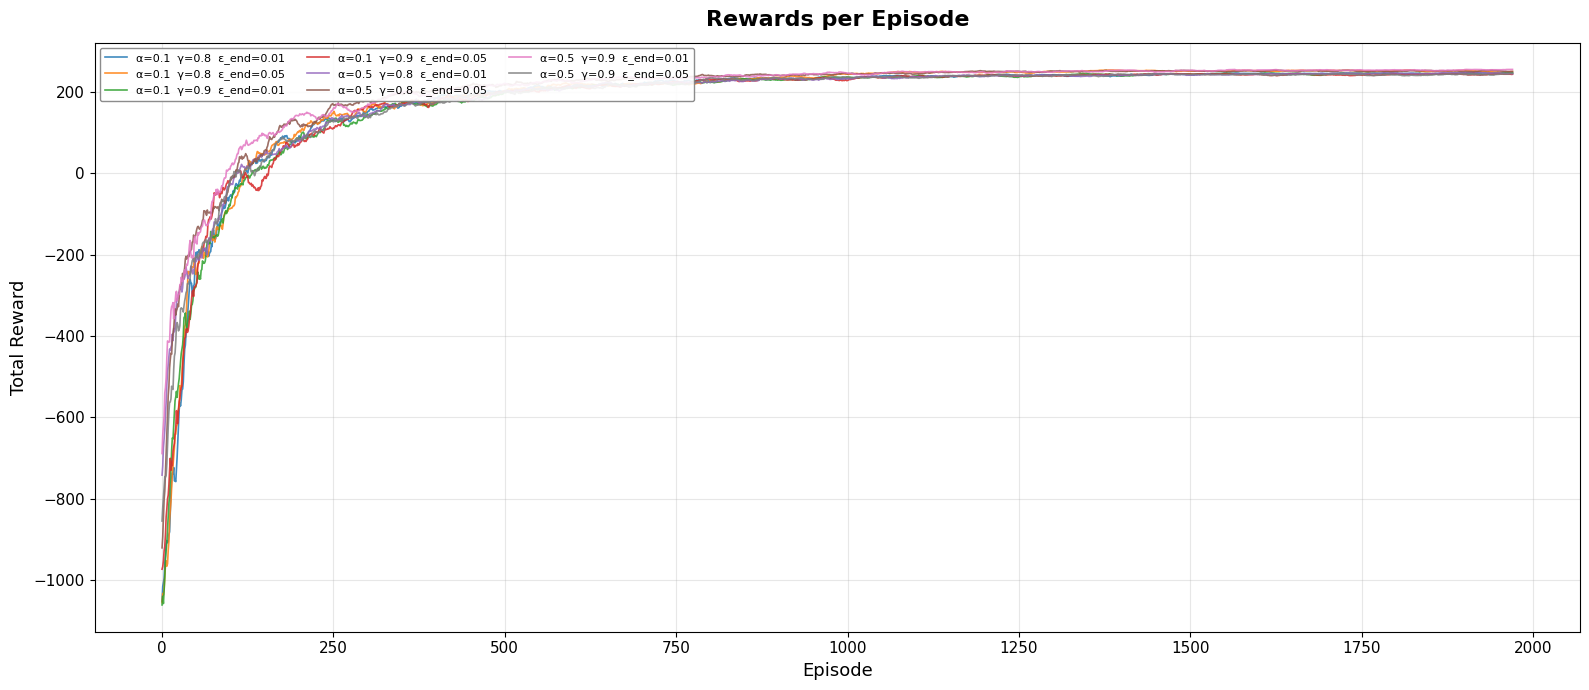

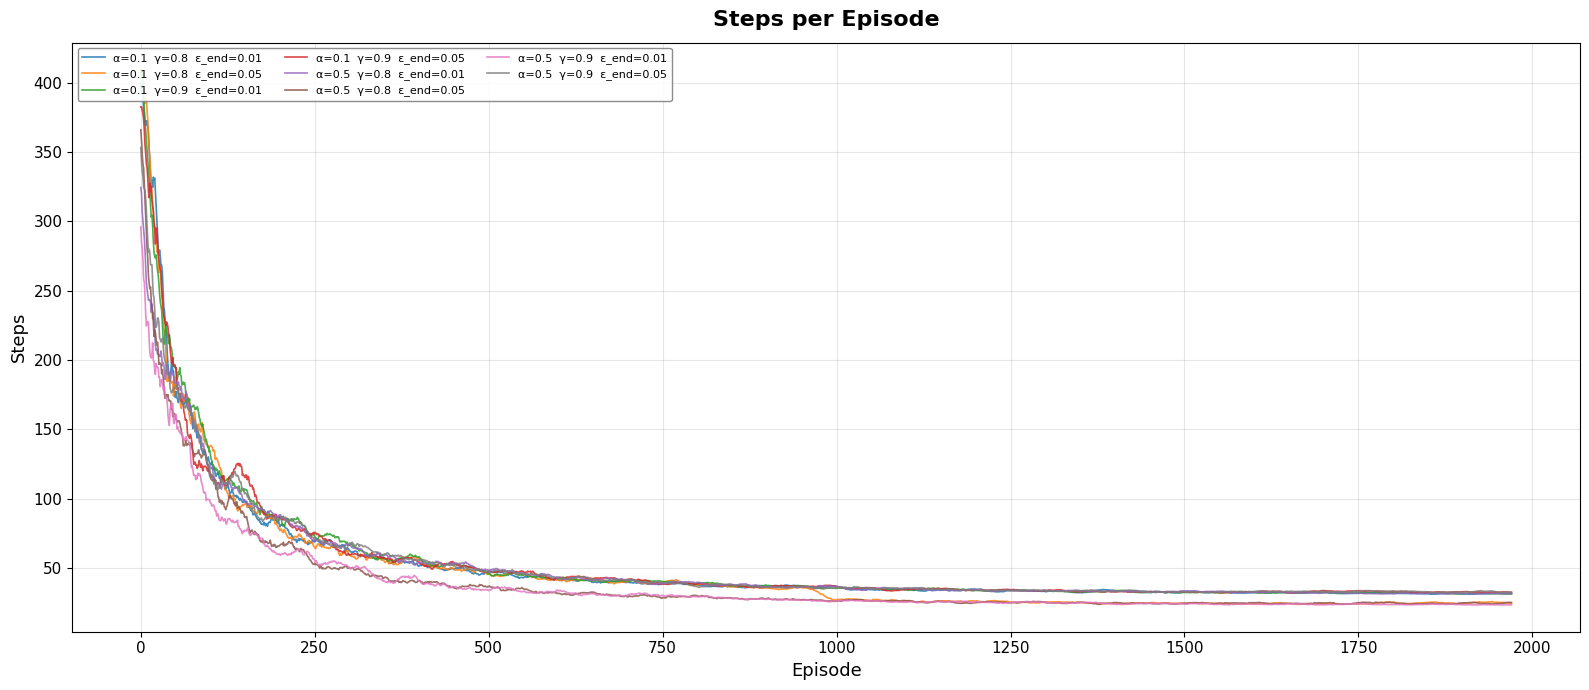

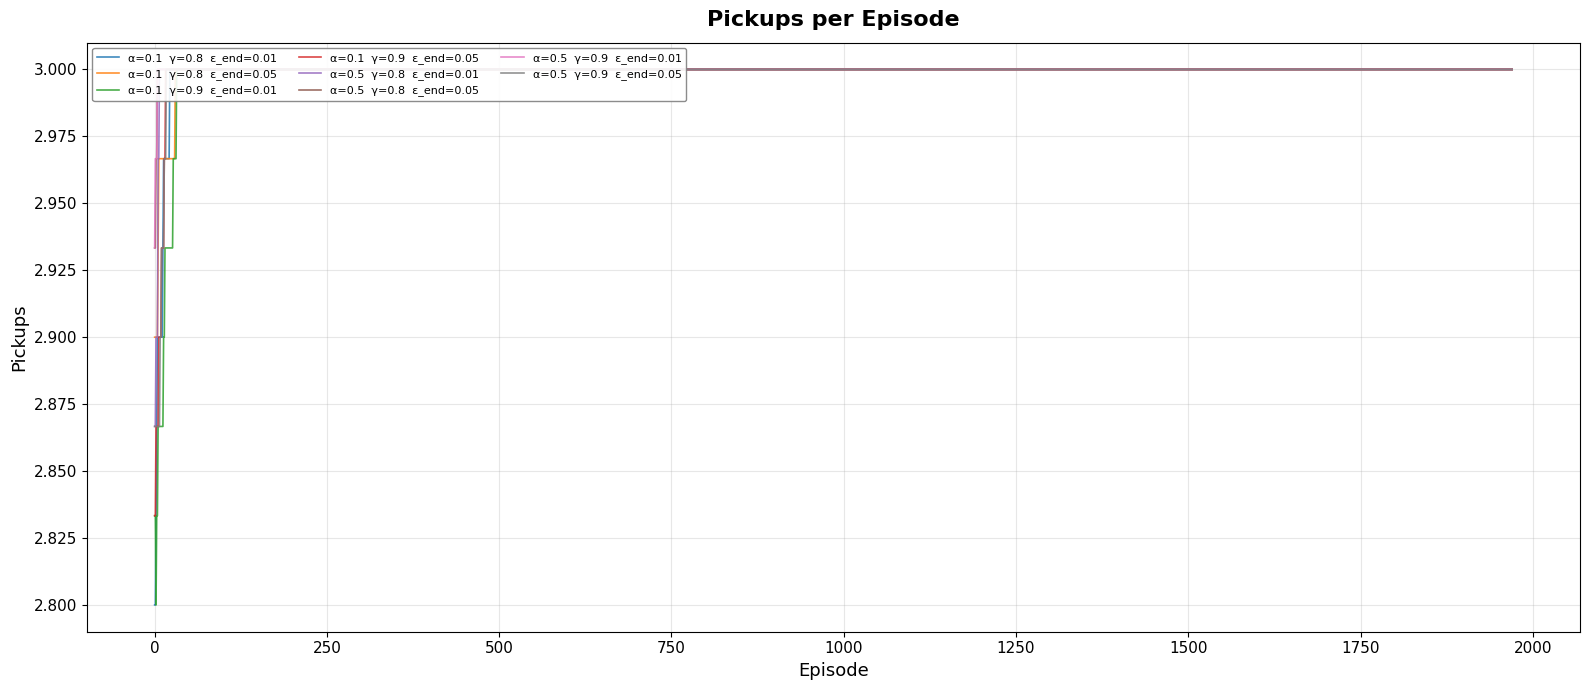

In [ ]:
def smooth(data, window=30):
    return np.convolve(data, np.ones(window)/window, mode='valid')

metrics = [
    ("rewards", "Total Reward",  "Rewards per Episode"),
    ("steps",   "Steps",         "Steps per Episode"),
    ("pickups", "Pickups",        "Pickups per Episode"),
]

for key, ylabel, title in metrics:
    fig, ax = plt.subplots(figsize=(16, 7))

    for (alpha, gamma, eps_end), data in all_results.items():
        label = f"α={alpha}  γ={gamma}  ε_end={eps_end}"
        ax.plot(smooth(data[key]), linewidth=1.2, label=label, alpha=0.85)

    ax.set_title(title, fontsize=16, fontweight='bold', pad=12)
    ax.set_xlabel("Episode", fontsize=13)
    ax.set_ylabel(ylabel, fontsize=13)
    ax.tick_params(labelsize=11)
    ax.legend(fontsize=8, ncol=3, loc="upper left",
              framealpha=0.9, edgecolor='grey')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"grid_search_{key}.png", dpi=150)
    plt.show()